# 05 — Challenger Model: Gradient-Boosted Trees (XGBoost)

**Project:** Can Search-Trend Data Improve Short-Horizon Macro Nowcasts? A Gradient-Boosting Approach


**Notebook purpose:** Fit the ML challenger — an XGBoost regressor trained on lagged FRED and Google Trends features — under the *same* expanding-window, one-step-ahead evaluation protocol as the ARIMA benchmark in `04_modeling_benchmark.ipynb`, so the two RMSEs are directly comparable. Also report SHAP-based feature importance to address interpretability concerns.

---

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.utils import load_config, get_path, shap_xgboost_base_score_compat
from src.models import run_ml_challenger
from src.evaluate import rmse, mae

config = load_config('../config.yaml')
feature_df = pd.read_csv('../data/processed/feature_matrix.csv', parse_dates=['date'], index_col='date')
target_col = config['target']['fred_series']
feature_df.tail()

,UNRATE,UNRATE_lag1,UNRATE_lag2,UNRATE_lag3,ICSA_lag1,ICSA_lag2,ICSA_lag3,INDPRO_lag1,INDPRO_lag2,INDPRO_lag3,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
date,,,,,,,,,,,,,,,,,,,,,
2024-08-31,4.2,4.2,4.1,3.9,237250.0,234800.0,222000.0,99.9757,100.8940,100.8630,...,False,False,False,False,False,True,False,False,False,False
2024-09-30,4.1,4.2,4.2,4.1,230600.0,237250.0,234800.0,100.4309,99.9757,100.8940,...,False,False,False,False,False,False,True,False,False,False
2024-10-31,4.1,4.1,4.2,4.2,224500.0,230600.0,237250.0,99.8084,100.4309,99.9757,...,False,False,False,False,False,False,False,True,False,False
2024-11-30,4.2,4.1,4.1,4.2,236250.0,224500.0,230600.0,99.4695,99.8084,100.4309,...,False,False,False,False,False,False,False,False,True,False
2024-12-31,4.1,4.2,4.1,4.1,219200.0,236250.0,224500.0,99.2925,99.4695,99.8084,...,False,False,False,False,False,False,False,False,False,True


## 1. Expanding-window XGBoost forecasts

Identical protocol to the ARIMA benchmark: refit at every step using only data strictly before the forecast date, over the same `test_window_months` held-out window.

In [2]:
ml_result, final_model = run_ml_challenger(
    feature_df,
    target_col=target_col,
    test_window_months=config['modeling']['test_window_months'],
    xgb_params=config['modeling']['xgboost'],
    random_state=config['modeling']['random_state'],
)
ml_df = ml_result.to_frame('xgb')
ml_df.tail()

,y_true,y_pred_xgb
date,,
2024-08-31,4.2,4.056743
2024-09-30,4.1,4.234187
2024-10-31,4.1,4.142831
2024-11-30,4.2,4.138800
2024-12-31,4.1,4.123302


## 2. Challenger accuracy

In [3]:
xgb_rmse = rmse(ml_df['y_true'], ml_df['y_pred_xgb'])
xgb_mae = mae(ml_df['y_true'], ml_df['y_pred_xgb'])
print(f'XGBoost out-of-sample RMSE: {xgb_rmse:.4f}')
print(f'XGBoost out-of-sample MAE:  {xgb_mae:.4f}')

XGBoost out-of-sample RMSE: 1.4185
XGBoost out-of-sample MAE:  0.4701


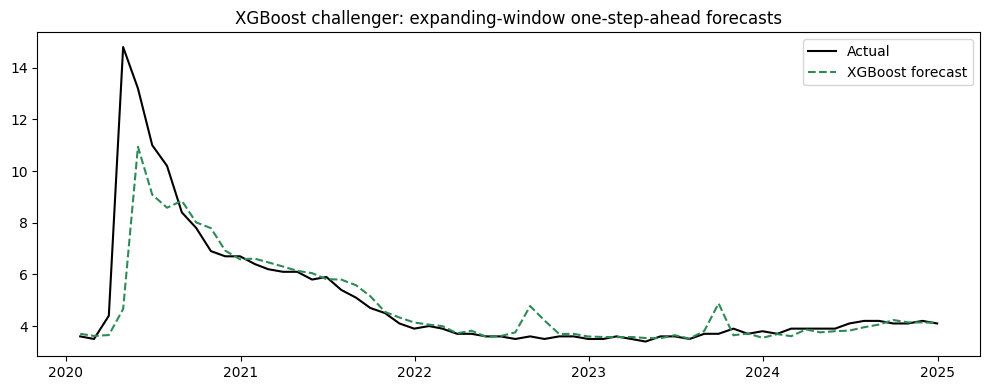

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(ml_df.index, ml_df['y_true'], label='Actual', color='black')
plt.plot(ml_df.index, ml_df['y_pred_xgb'], label='XGBoost forecast', color='seagreen', linestyle='--')
plt.legend()
plt.title('XGBoost challenger: expanding-window one-step-ahead forecasts')
plt.tight_layout()
plt.savefig('../reports/fig_xgb_challenger.png', dpi=150)
plt.show()

## 3. Interpretability: SHAP feature importance

SHAP values quantify each feature's contribution to individual predictions, directly addressing the common referee objection that tree-ensemble nowcasts are an uninterpretable black box.

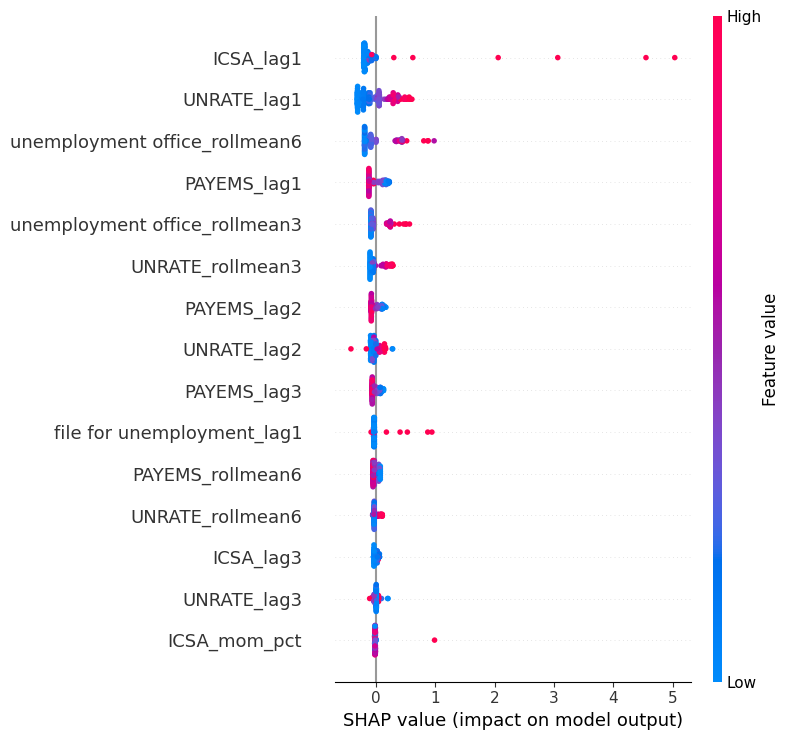

In [5]:
feature_cols = [c for c in feature_df.columns if c != target_col]
with shap_xgboost_base_score_compat():
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(feature_df[feature_cols])

shap.summary_plot(shap_values, feature_df[feature_cols], show=False, max_display=15)
plt.tight_layout()
plt.savefig('../reports/fig_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Persist challenger results

In [6]:
out_path = get_path(config['paths']['processed_dir'] + '/results_xgb.csv')
ml_df.to_csv(out_path)
print(f'Saved XGBoost results to {out_path}')

Saved XGBoost results to E:\Research_Projects\Economics_Bulletin\econ-ml-nowcasting\data\processed\results_xgb.csv


---
## Notebook summary

- Fit an XGBoost challenger under the identical expanding-window, one-step-ahead protocol used for the ARIMA benchmark.
- Generated a SHAP summary plot identifying which lagged FRED/Trends features drive the model's predictions.
- Saved forecasts to `data/processed/results_xgb.csv`.

**Next notebook:** `06_evaluation_and_results.ipynb` — head-to-head comparison and the Diebold-Mariano test for equal predictive accuracy.